<a href="https://colab.research.google.com/github/manuelabarcarodriguez/Spectral-graph-theory/blob/main/Spectral_drawing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

One of the applications of spectral graph theory is the spectral drawing. In this notebook we present one example of how good this simple algorithm works when drawing graphs that are planar and most of its faces are triangulated.

In [2]:
#Imports
!pip install networkx numpy scipy matplotlib --quiet

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from scipy.linalg import eigh

We first generate the graph. First of all, we create a regular grid, and then we add some random noise in order to get a "not-so-regular" example. We then perform a Delunay triangulation. In essence, it transforms each face in triangles with certain conditions.

In [4]:
#Generation of the graph. We use Delunay triangulation over a mesh with noise. This yields a planar graph

np.random.seed(19)

#Base 8 x 8 mesh with some noise so we dont get a perfectly reegular mesh
grid_n = 8
xs = np.linspace(0, 1, grid_n)
ys = np.linspace(0, 1, grid_n)
xx, yy = np.meshgrid(xs, ys)
points = np.column_stack([xx.ravel(), yy.ravel()])
points += np.random.normal(0, 0.04, points.shape)   # soft noise
points = np.clip(points, 0, 1)

n = len(points)
print(f"Número de vértices: {n}")

# delunay triangulation
tri = Delaunay(points)
G = nx.Graph()
G.add_nodes_from(range(n))

for simplex in tri.simplices:         # each simplex is a triangle (3 vertices)
    i, j, k = simplex
    G.add_edge(i, j)
    G.add_edge(j, k)
    G.add_edge(i, k)

print(f"Número de aristas: {G.number_of_edges()}")
print(f"Grado medio: {2 * G.number_of_edges() / n:.2f}")

#We save the real position of the points
pos_real = {i: (points[i, 0], points[i, 1]) for i in range(n)}

Número de vértices: 64
Número de aristas: 173
Grado medio: 5.41


In [17]:
#We build the adjacency matrix

A = nx.to_numpy_array(G, dtype=float)

print("Adjacency matrix A (first 8 rows/columns):")
print(np.array2string(A[:8, :8], formatter={'float_kind': lambda x: f"{int(x)}"}))
print(f"\nDimensions: {A.shape}")
print(f"Degree of vertex 0: {int(A[0].sum())}")

Adjacency matrix A (first 8 rows/columns):
[[0 1 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0]
 [0 1 0 1 1 0 0 0]
 [0 0 1 0 1 0 0 0]
 [0 0 1 1 0 1 1 0]
 [0 0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 1 0]]

Dimensions: (64, 64)
Degree of vertex 0: 3


In general, drawing graphs nicely is not an easy task. However, if we represent the vertices randomly, almost surely we are going to get a chaotic view of the graph.



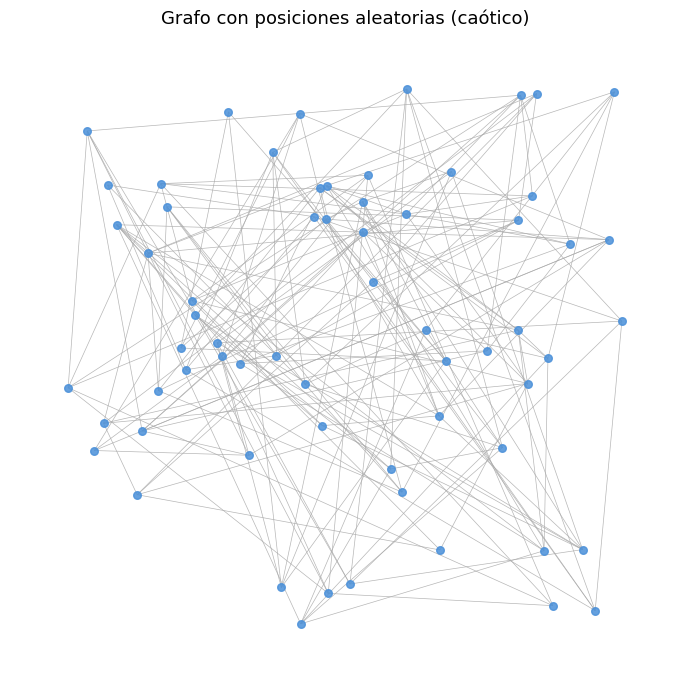

Imagen guardada como 'grafo_aleatorio.png'


In [14]:
#We asign random positions to the vertices so we get a chaotic drawing

np.random.seed(7)
pos_random = {i: (np.random.uniform(0, 1), np.random.uniform(0, 1)) for i in range(n)}

fig, ax = plt.subplots(figsize=(7, 7))
nx.draw(
    G, pos=pos_random, ax=ax,
    node_size=30, node_color="#4A90D9",
    edge_color="#AAAAAA", width=0.5, alpha=0.85,
    with_labels=False
)
ax.set_title("Grafo con posiciones aleatorias (caótico)", fontsize=13)
plt.tight_layout()
plt.savefig("grafo_aleatorio.png", dpi=150)
plt.show()
print("Imagen guardada como 'grafo_aleatorio.png'")

Now we apply the spectral drawing algorithm. This is as easy as calculating the first two nontrivial eigenvectors of the laplactian matrix and assigning each vertex the (x,y) coordinates determined by the two eigenvectors. If the graph is connected, these eigenvectors are the second and the third one, since the first one is always constant.

First 6 eigenvalues of the Laplacian:
[-0.        0.290608  0.358847  0.753655  1.049279  1.151867]


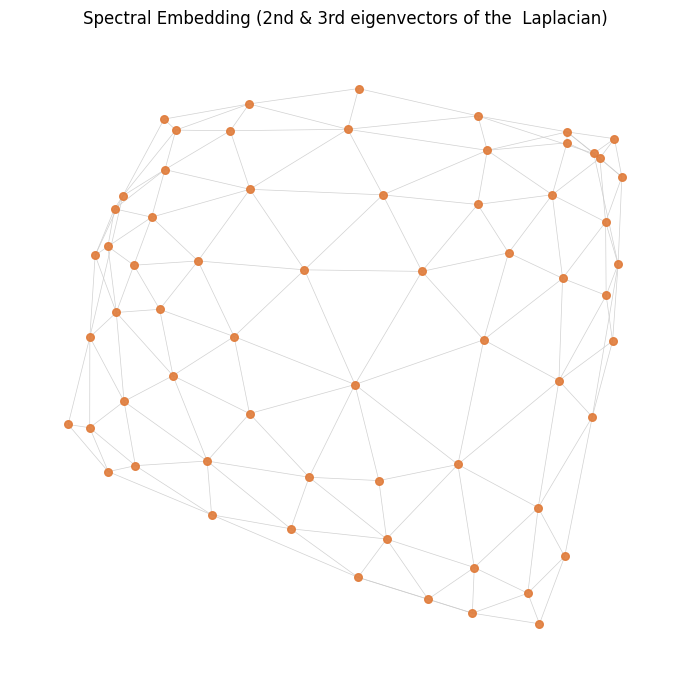

Imagen guardada como 'grafo_spectral.png'


In [15]:
#We compute the laplatian L = D-A, the second and third eigenvectors and asign each vertex its corresponding coordinates

# Degree matrix D
degrees = A.sum(axis=1)
D = np.diag(degrees)

# Laplacian
L = D - A

#Eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(L)

print("First 6 eigenvalues of the Laplacian:")
print(np.round(eigenvalues[:6], 6))

# the first eigenvector is always constant

x_spec = eigenvectors[:, 1]   # Fiedler vector
y_spec = eigenvectors[:, 2]

pos_spectral = {i: (x_spec[i], y_spec[i]) for i in range(n)}

fig, ax = plt.subplots(figsize=(7, 7))
nx.draw(
    G, pos=pos_spectral, ax=ax,
    node_size=30, node_color="#E07B39",
    edge_color="#CCCCCC", width=0.5, alpha=0.9,
    with_labels=False
)
ax.set_title("Spectral Embedding (2nd & 3rd eigenvectors of the  Laplacian)", fontsize=12)
plt.tight_layout()
plt.savefig("grafo_spectral.png", dpi=150)
plt.show()
print("Imagen guardada como 'grafo_spectral.png'")

Lastly, we present a comparison of a planar drawing of the graph, the chaotic drawing and the spectraly drawn graph.

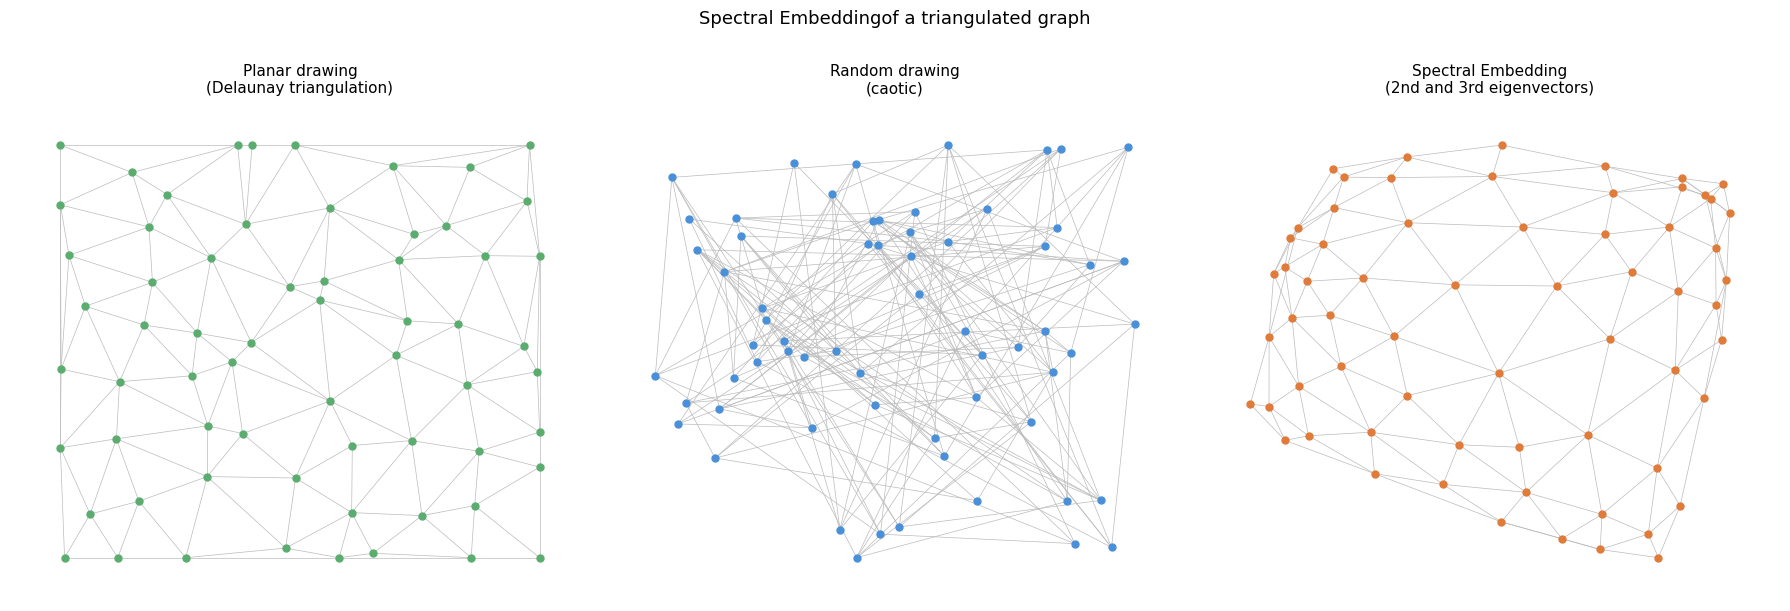

Comparativa guardada como 'comparativa.png'


In [16]:
# ── Celda 6: Comparativa — original, aleatorio y spectral ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

draw_kw = dict(node_size=25, edge_color="#BBBBBB", width=0.5, with_labels=False)

nx.draw(G, pos=pos_real,     ax=axes[0], node_color="#5BAD6F", **draw_kw)
axes[0].set_title("Planar drawing\n(Delaunay triangulation)", fontsize=11)

nx.draw(G, pos=pos_random,   ax=axes[1], node_color="#4A90D9", **draw_kw)
axes[1].set_title("Random drawing\n(chaotic)", fontsize=11)

nx.draw(G, pos=pos_spectral, ax=axes[2], node_color="#E07B39", **draw_kw)
axes[2].set_title("Spectral Embedding\n(2nd and 3rd eigenvectors)", fontsize=11)

plt.suptitle("Spectral Embeddingof a triangulated graph", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparativa guardada como 'comparativa.png'")